In [1]:
#1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#2. Lectura de archivo
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

housing = pd.read_csv(url)

In [3]:
#3. Examinar datos
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
#4. Información general
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
#5. Imputar valores faltantes
# Calcular la mediana
mediana_bedrooms = housing["total_bedrooms"].median()

# Reemplazar valores faltantes
housing.fillna({"total_bedrooms": mediana_bedrooms}, inplace=True)

In [7]:
#6. Conversión de variable
# Aplicar One-Hot Encoding
housing = pd.get_dummies(housing, columns=["ocean_proximity"])

In [8]:
#7. Verificar cambios
housing.info()
housing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  bool   
 10  ocean_proximity_INLAND      20640 non-null  bool   
 11  ocean_proximity_ISLAND      20640 non-null  bool   
 12  ocean_proximity_NEAR BAY    20640 non-null  bool   
 13  ocean_proximity_NEAR OCEAN  206

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [9]:
#8. Separar variables
# Variable objetivo
y = housing["median_house_value"]

# Variables predictoras
X = housing.drop("median_house_value", axis=1)

In [10]:
#9. División de dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
#10. Crear modelo
modelo = LinearRegression()

In [12]:
#11. Entrenar modelo
modelo.fit(X_train, y_train)

LinearRegression()

Para instalar una biblioteca, usa el comando `!pip install` seguido del nombre de la biblioteca.

In [13]:
#12. Predicciones
y_pred = modelo.predict(X_test)

In [14]:
#13. Calcular métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Coeficiente R²:", r2)

Mean Squared Error (MSE): 4908476721.156623
Coeficiente R²: 0.6254240620553602


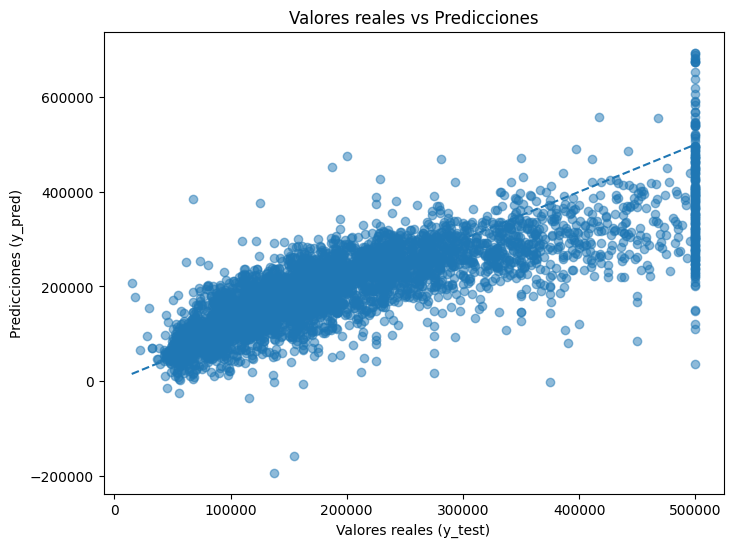

In [15]:
#14. Visualización con diagrama de dispersión
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Valores reales vs Predicciones")

# Línea de referencia (ajuste perfecto)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

In [19]:
#15. Guardar cuaderno
import joblib
from google.colab import files
joblib.dump(modelo, 'modelo_regresion.pkl')

['modelo_regresion.pkl']

In [21]:
#16. Descargar archivo
files.download('modelo_regresion.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys
!{sys.executable} -m pip install pandas

Si la biblioteca ya está instalada, puedes asegurarte de tener la última versión usando el argumento `--upgrade`.

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pandas